# Matched IsoNCA LPPN decoder experiments

Colab notebook for the controlled study in `docs/isonca_isotropic_lppn_experiments_2026-07-23.md`.

The `lap_gradnorm` IsoNCA, lizard target, invariant loss, living-mask gating, alpha supervision, pool schedule, and optimizer are held fixed. One selected decoder is trained per run:

- `cartesian_coords`: the original Cartesian sub-cell-coordinate LPPN quality baseline.
- `isotropic_neighbors`: the proposed four-cell, shared-message, permutation-invariant decoder without geometric inputs.
- `isotropic_neighbors_radial`: the same decoder with radial distance as a controlled extension.
- `interpolated_only`: the completed no-coordinate baseline, included for smoke tests or a fresh replication.

Use a GPU runtime. Checkpoints are written to Google Drive every 5,000 steps and resume automatically. The decoder-only test uses arbitrary non-symmetric fields; the end-to-end test uses paired stochastic update masks so it does not collapse to the deterministic radial-disk diagnostic from the earlier notebook.

In [5]:
#@title Clone/update repository (Colab setup)
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = 'https://github.com/IvanLudvig/Cells2Pixels.git'
BRANCH = 'isotropic'
REPO_DIR = 'Cells2Pixels'

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if not Path('train.py').exists():
    if not Path(REPO_DIR).exists():
        subprocess.run(['git', 'clone', '--branch', BRANCH, REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
elif IN_COLAB and Path('.git').exists():
    subprocess.run(['git', 'pull', '--ff-only'], check=True)

if not Path('models/isotropic_lppn.py').exists():
    raise FileNotFoundError(
        'models/isotropic_lppn.py is missing. Commit and push the prepared experiment files to the selected branch before running Colab.'
    )
print('cwd:', Path.cwd())
print('branch:', subprocess.run(['git', 'branch', '--show-current'], capture_output=True, text=True).stdout.strip())

cwd: /content/Cells2Pixels
branch: isotropic


In [6]:
#@title Imports and device setup
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import random
import requests
import torch
import torch.nn.functional as F
from IPython.display import clear_output, display
from PIL import Image

from losses.invariant_image_loss import InvariantImageLoss
from models.isonca import GradNormIsoGrowingNCA
from models.isotropic_lppn import IsotropicNeighborhoodLPPN
from models.siren import Siren
from training.common import make_grad_scaler, normalize_model_grads, optimizer_scheduler_step, set_seed
from utils.misc import autocast_context
from utils.render import Renderer2D

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Torch:', torch.__version__)
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('WARNING: training on CPU will be very slow; select a Colab GPU runtime.')

Torch: 2.11.0+cu128
Device: cuda:0
GPU: Tesla T4


Target: data/morphology_png/lizard.png | size: (512, 512)


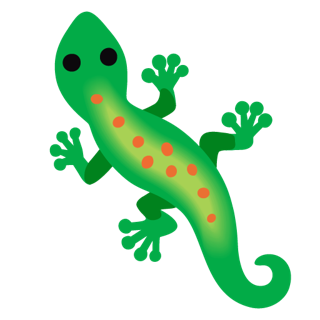

In [7]:
#@title Prepare the Noto lizard target
TARGET_IMAGE_PATH = Path('data/morphology_png/lizard.png')
LIZARD_URL = 'https://github.com/googlefonts/noto-emoji/blob/main/png/512/emoji_u1f98e.png?raw=true'

def ensure_lizard_target(path):
    path = Path(path)
    if path.exists():
        return path
    path.parent.mkdir(parents=True, exist_ok=True)
    response = requests.get(
        LIZARD_URL,
        headers={'User-Agent': 'Cells2Pixels IsoNCA notebook'},
        timeout=60,
    )
    response.raise_for_status()
    Image.open(BytesIO(response.content)).convert('RGBA').save(path)
    return path

ensure_lizard_target(TARGET_IMAGE_PATH)
target_preview = Image.open(TARGET_IMAGE_PATH).convert('RGBA')
print('Target:', TARGET_IMAGE_PATH, '| size:', target_preview.size)
display(target_preview.resize((320, 320)))

In [8]:
#@title Experiment settings
VARIANT_TO_RUN = 'isotropic_neighbors'  #@param ['cartesian_coords', 'isotropic_neighbors', 'isotropic_neighbors_radial', 'interpolated_only']
TRAIN_STEPS = 50000  #@param {type: 'integer'}
BATCH_SIZE = 2  #@param {type: 'integer'}
USE_GOOGLE_DRIVE = True  #@param {type: 'boolean'}
RESUME_FROM_CHECKPOINT = True  #@param {type: 'boolean'}

SEED = 43
PRECISION = torch.float32  # FFT loss + long unroll overflowed under AMP/fp16 on a T4.
IMAGE_SIZE = (512, 512)
PADDING = (32, 32)
SCALE_FACTOR = 8
CHANNELS = 16
FC_DIM = 128
UPDATE_PROB = 0.5

SIREN_HIDDEN = 96
SIREN_LAYERS = 2
SIREN_FREQUENCIES = 1
MESSAGE_FEATURES = 48
NEIGHBOR_HIDDEN = 96
PHI_HIDDEN_LAYERS = 1
RHO_HIDDEN_LAYERS = 1

POOL_SIZE = 256
STEP_RANGE = (64, 96)
EARLY_SEED_STEPS = 4000
SUMMARY_INTERVAL = 500
CHECKPOINT_INTERVAL = 5000
DAMAGE_ENABLED = False
SUPERVISE_NCA_ALPHA = True

LR = 1e-3
LR_BASE = 1e-5
LR_CYCLE_STEP_UP = 2000
OVERFLOW_WEIGHT = 10.0
DIFF_WEIGHT = 10.0
EVAL_STEPS = 96

if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
    except ImportError:
        CHECKPOINT_ROOT = Path('notebook_runs')
        print('Google Drive unavailable; using local notebook_runs/.')
    else:
        drive.mount('/content/drive')
        CHECKPOINT_ROOT = Path('/content/drive/MyDrive/Cells2Pixels/notebook_runs')
else:
    CHECKPOINT_ROOT = Path('notebook_runs')
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)
set_seed(SEED)
print('Selected variant:', VARIANT_TO_RUN)
print('Checkpoint root:', CHECKPOINT_ROOT)

Mounted at /content/drive
Selected variant: isotropic_neighbors
Checkpoint root: /content/drive/MyDrive/Cells2Pixels/notebook_runs


In [9]:
#@title Build and render helpers
def make_loss():
    return InvariantImageLoss(
        target_path=str(TARGET_IMAGE_PATH),
        image_size=IMAGE_SIZE,
        padding=PADDING,
        premultiply_alpha=True,
        aux_type='binary',
        mirror=True,
        sharpen=True,
        l2_weight=1.0,
        include_nca_alpha=SUPERVISE_NCA_ALPHA,
        device=device,
    )

def make_seed(model, n, h, w):
    return model.seed(n, h, w).to(device=device, dtype=PRECISION)

def make_decoder(name, out_features, scale_factor=SCALE_FACTOR):
    if name in {'cartesian_coords', 'interpolated_only'}:
        return Siren(
            in_features=CHANNELS,
            coord_dim=2,
            out_features=out_features,
            hidden_features=SIREN_HIDDEN,
            hidden_layers=SIREN_LAYERS,
            outermost_linear=True,
            fx='linear',
            activation='sin',
            num_frequencies=SIREN_FREQUENCIES,
            first_omega_0=10.0,
            hidden_omega_0=10.0,
            disable=False,
            disable_coords=(name == 'interpolated_only'),
        ).to(device)
    if name in {'isotropic_neighbors', 'isotropic_neighbors_radial'}:
        return IsotropicNeighborhoodLPPN(
            in_features=CHANNELS,
            out_features=out_features,
            scale_factor=scale_factor,
            message_features=MESSAGE_FEATURES,
            hidden_features=NEIGHBOR_HIDDEN,
            phi_hidden_layers=PHI_HIDDEN_LAYERS,
            rho_hidden_layers=RHO_HIDDEN_LAYERS,
            radial_distance=(name == 'isotropic_neighbors_radial'),
            aggregation='mean',
        ).to(device)
    raise ValueError(f'Unknown decoder variant: {name}')

def make_renderer(scale_factor=SCALE_FACTOR):
    return Renderer2D(
        scale_factor=scale_factor,
        padding='circular',
        fs_shader='vanilla',
        precision=PRECISION,
    )

def decode_raw(name, decoder, renderer, state, scale_factor=None, neighbor_permutation=None):
    if name.startswith('isotropic_neighbors'):
        return decoder(
            state.to(torch.float32),
            scale_factor=scale_factor,
            neighbor_permutation=neighbor_permutation,
        ).to(torch.float32)
    if neighbor_permutation is not None:
        raise ValueError('neighbor_permutation applies only to neighborhood decoders')
    if scale_factor is not None and scale_factor != renderer.scale_factor:
        renderer = make_renderer(scale_factor)
    return renderer.render(
        state.to(torch.float32).permute(0, 2, 3, 1),
        decoder,
        None,
        fs_shader='vanilla',
        hard_clamp=False,
    ).to(torch.float32)

def render_channels(name, model, decoder, renderer, state, scale_factor=None):
    image = decode_raw(name, decoder, renderer, state, scale_factor=scale_factor)
    x_up = F.interpolate(
        state.to(torch.float32),
        size=image.shape[1:3],
        mode='bilinear',
        align_corners=False,
    )
    living_mask = model.get_living_mask(x_up).to(image.dtype).permute(0, 2, 3, 1)
    return image * living_mask

def build_variant(name):
    loss_fn = make_loss()
    model = GradNormIsoGrowingNCA(
        channels=CHANNELS,
        fc_dim=FC_DIM,
        update_prob=UPDATE_PROB,
        device=device,
        precision=PRECISION,
    ).to(device)
    decoder = make_decoder(name, loss_fn.channel_n)
    renderer = make_renderer()
    grid_size = (
        loss_fn.grid_size[0] // SCALE_FACTOR,
        loss_fn.grid_size[1] // SCALE_FACTOR,
    )
    parameter_n = sum(p.numel() for p in decoder.parameters())
    print(name, '| render:', loss_fn.grid_size, '| NCA:', grid_size, '| decoder params:', f'{parameter_n:,}')
    return model, decoder, loss_fn, renderer, grid_size

def composite_rgba(image):
    image = np.asarray(image)
    rgb = np.clip(image[..., :3], 0.0, 1.0)
    alpha = np.clip(image[..., 3:4], 0.0, 1.0)
    return rgb + (1.0 - alpha)

def total_grad_norm(module):
    norms = [p.grad.detach().float().norm() for p in module.parameters() if p.grad is not None]
    return torch.linalg.vector_norm(torch.stack(norms)) if norms else torch.zeros((), device=device)

In [10]:
#@title Checkpoint helpers
DIRECTORY_NAMES = {
    'interpolated_only': 'isonca_lizard_lppn_no_coords',
    'cartesian_coords': 'isonca_lizard_lppn_coords',
    'isotropic_neighbors': 'isonca_lizard_lppn_isotropic_neighbors',
    'isotropic_neighbors_radial': 'isonca_lizard_lppn_isotropic_neighbors_radial',
}

def variant_output_dir(name, create=True):
    path = CHECKPOINT_ROOT / DIRECTORY_NAMES[name]
    if create:
        path.mkdir(parents=True, exist_ok=True)
    return path

def make_scheduler(optimizer):
    return torch.optim.lr_scheduler.CyclicLR(
        optimizer,
        base_lr=LR_BASE,
        max_lr=LR,
        step_size_up=LR_CYCLE_STEP_UP,
        mode='triangular2',
        cycle_momentum=False,
    )

def save_training_checkpoint(name, step, model, decoder, optimizer, scheduler, scaler, pool, history):
    path = variant_output_dir(name) / 'latest.pt'
    temporary_path = path.with_suffix('.tmp')
    checkpoint = {
        'version': 2,
        'variant': name,
        'step': step,
        'model': model.state_dict(),
        'decoder': decoder.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'scaler': scaler.state_dict(),
        'pool': pool.detach().cpu(),
        'history': history,
        'torch_rng_state': torch.get_rng_state(),
        'cuda_rng_state_all': torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
        'numpy_rng_state': np.random.get_state(),
        'python_rng_state': random.getstate(),
        'grid_size': tuple(pool.shape[-2:]),
        'pool_size': len(pool),
    }
    torch.save(checkpoint, temporary_path)
    os.replace(temporary_path, path)
    print(f'checkpoint saved: {path} (step {step})')

def restore_training_checkpoint(name, model, decoder, optimizer, scheduler, scaler, pool):
    path = variant_output_dir(name) / 'latest.pt'
    if not RESUME_FROM_CHECKPOINT or not path.exists():
        return 0, pool, []
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    checkpoint_variant = checkpoint.get('variant')
    accepted_names = {name}
    if name == 'interpolated_only':
        accepted_names.add('no_coords')
    if name == 'cartesian_coords':
        accepted_names.add('coords')
    if checkpoint_variant not in accepted_names:
        raise ValueError(f'Checkpoint variant mismatch: {checkpoint_variant} not in {accepted_names}')
    restored_pool = checkpoint['pool'].to(device=device, dtype=PRECISION)
    if restored_pool.shape != pool.shape:
        raise ValueError(f'Checkpoint pool {tuple(restored_pool.shape)} != expected {tuple(pool.shape)}')
    model.load_state_dict(checkpoint['model'])
    decoder.load_state_dict(checkpoint.get('decoder', checkpoint.get('siren')))
    optimizer.load_state_dict(checkpoint['optimizer'])
    scheduler.load_state_dict(checkpoint['scheduler'])
    scaler.load_state_dict(checkpoint.get('scaler', {}))
    torch.set_rng_state(checkpoint['torch_rng_state'].cpu())
    if torch.cuda.is_available() and checkpoint.get('cuda_rng_state_all') is not None:
        torch.cuda.set_rng_state_all([state.cpu() for state in checkpoint['cuda_rng_state_all']])
    np.random.set_state(checkpoint['numpy_rng_state'])
    random.setstate(checkpoint['python_rng_state'])
    start_step = int(checkpoint['step']) + 1
    print(f'resumed: {path} (next step {start_step})')
    return start_step, restored_pool, checkpoint.get('history', [])

In [11]:
#@title Decoder-only D4 and permutation preflight (run before training)
def rel_l2(a, b):
    return (
        torch.linalg.vector_norm((a - b).reshape(a.shape[0], -1), dim=1)
        / (torch.linalg.vector_norm(b.reshape(b.shape[0], -1), dim=1) + 1e-8)
    )

D4_TRANSFORMS = [
    ('rot90', lambda x: torch.rot90(x, 1, (-2, -1)), lambda x: torch.rot90(x, 1, (-3, -2))),
    ('rot180', lambda x: torch.rot90(x, 2, (-2, -1)), lambda x: torch.rot90(x, 2, (-3, -2))),
    ('rot270', lambda x: torch.rot90(x, 3, (-2, -1)), lambda x: torch.rot90(x, 3, (-3, -2))),
    ('flip_x', lambda x: torch.flip(x, (-1,)), lambda x: torch.flip(x, (-2,))),
    ('flip_y', lambda x: torch.flip(x, (-2,)), lambda x: torch.flip(x, (-3,))),
]

@torch.no_grad()
def decoder_d4_rows(name, decoder, renderer, state):
    base = decode_raw(name, decoder, renderer, state)
    rows = []
    for label, transform_state, transform_image in D4_TRANSFORMS:
        actual = decode_raw(name, decoder, renderer, transform_state(state))
        expected = transform_image(base)
        rows.append((label, (actual - expected).abs().mean().item(), rel_l2(actual, expected).mean().item()))
    return rows

set_seed(SEED)
preflight_state = torch.randn(1, CHANNELS, 9, 9, device=device)
for preflight_name in ['interpolated_only', 'cartesian_coords', 'isotropic_neighbors', 'isotropic_neighbors_radial']:
    preflight_decoder = make_decoder(preflight_name, out_features=5, scale_factor=4)
    preflight_renderer = make_renderer(scale_factor=4)
    rows = decoder_d4_rows(preflight_name, preflight_decoder, preflight_renderer, preflight_state)
    max_error = max(row[2] for row in rows)
    print('\n' + preflight_name, '| params:', f'{sum(p.numel() for p in preflight_decoder.parameters()):,}')
    for label, mae, relative in rows:
        print(f'  {label:7s}  mae={mae:.3e}  rel_l2={relative:.3e}')
    if preflight_name == 'interpolated_only':
        assert max_error < 5e-5
    if preflight_name.startswith('isotropic_neighbors'):
        with torch.no_grad():
            base = decode_raw(preflight_name, preflight_decoder, preflight_renderer, preflight_state)
            permuted = decode_raw(
                preflight_name,
                preflight_decoder,
                preflight_renderer,
                preflight_state,
                neighbor_permutation=[2, 0, 3, 1],
            )
        permutation_error = rel_l2(permuted, base).mean().item()
        print(f'  neighbor permutation rel_l2={permutation_error:.3e}')
        assert max_error < 5e-5 and permutation_error < 5e-5
del preflight_state, preflight_decoder, base, permuted
if device.type == 'cuda':
    torch.cuda.empty_cache()


interpolated_only | params: 21,125
  rot90    mae=1.974e-08  rel_l2=2.084e-07
  rot180   mae=1.928e-08  rel_l2=2.036e-07
  rot270   mae=1.976e-08  rel_l2=2.062e-07
  flip_x   mae=1.804e-08  rel_l2=1.913e-07
  flip_y   mae=1.778e-08  rel_l2=1.898e-07

cartesian_coords | params: 21,125
  rot90    mae=4.369e-02  rel_l2=4.775e-01
  rot180   mae=4.804e-02  rel_l2=5.013e-01
  rot270   mae=4.370e-02  rel_l2=4.774e-01
  flip_x   mae=3.692e-02  rel_l2=3.945e-01
  flip_y   mae=3.350e-02  rel_l2=3.489e-01

isotropic_neighbors | params: 22,325
  rot90    mae=1.115e-08  rel_l2=1.921e-07
  rot180   mae=1.125e-08  rel_l2=1.929e-07
  rot270   mae=1.095e-08  rel_l2=1.908e-07
  flip_x   mae=1.058e-08  rel_l2=1.843e-07
  flip_y   mae=1.121e-08  rel_l2=1.941e-07
  neighbor permutation rel_l2=1.487e-07

isotropic_neighbors_radial | params: 22,373
  rot90    mae=1.170e-08  rel_l2=1.476e-07
  rot180   mae=1.181e-08  rel_l2=1.492e-07
  rot270   mae=1.157e-08  rel_l2=1.466e-07
  flip_x   mae=1.113e-08  rel_l2

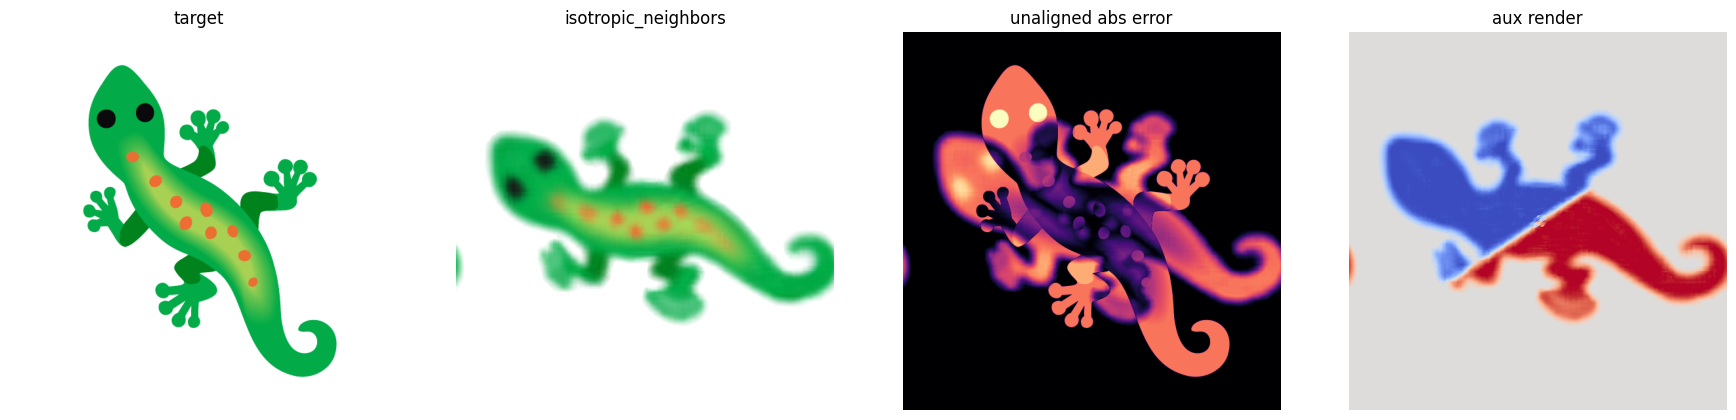

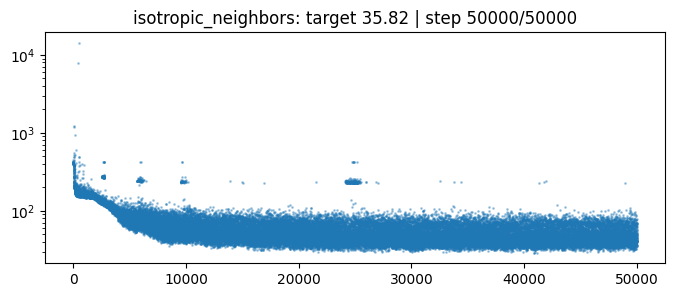

{'step': 50000, 'loss': 35.88949203491211, 'target': 35.82487487792969, 'overflow': 0.004161220509558916, 'diff': 0.0023006079718470573, 'model_grad': 659.1527709960938, 'decoder_grad': 136.40524291992188, 'lr': 1.0241578369140626e-05, 'step_n': 95}
checkpoint saved: /content/drive/MyDrive/Cells2Pixels/notebook_runs/isonca_lizard_lppn_isotropic_neighbors/latest.pt (step 50000)
saved: /content/drive/MyDrive/Cells2Pixels/notebook_runs/isonca_lizard_lppn_isotropic_neighbors


In [12]:
#@title Train/resume the selected variant
def reset_dead_samples(model, x):
    if len(x) <= 1:
        return x
    dead = (x[1:, 3:4].sum(dim=(1, 2, 3), keepdim=True) < 1e-6).to(x.dtype)
    if dead.any():
        seed = make_seed(model, len(x) - 1, x.shape[-2], x.shape[-1])
        x[1:] = dead * seed + (1.0 - dead) * x[1:]
    return x

def train_variant(name):
    set_seed(SEED)
    model, decoder, loss_fn, renderer, grid_size = build_variant(name)
    with torch.no_grad():
        pool = make_seed(model, POOL_SIZE, *grid_size)
    optimizer = torch.optim.Adam(list(model.parameters()) + list(decoder.parameters()), lr=LR_BASE)
    scheduler = make_scheduler(optimizer)
    scaler = make_grad_scaler(device, PRECISION)
    start_step, pool, history = restore_training_checkpoint(
        name, model, decoder, optimizer, scheduler, scaler, pool
    )

    model.train()
    decoder.train()
    for step in range(start_step, TRAIN_STEPS + 1):
        with torch.no_grad():
            batch_idx = np.random.choice(len(pool), BATCH_SIZE, replace=False)
            x = pool[batch_idx].clone()
            seed_rate = 1 if step < EARLY_SEED_STEPS else 6
            if step % seed_rate == 0:
                x[:1] = make_seed(model, 1, *grid_size)
            x = reset_dead_samples(model, x)

        step_n = np.random.randint(*STEP_RANGE)
        diff_loss = torch.zeros((), device=device, dtype=torch.float32)
        with autocast_context(device, PRECISION):
            for _ in range(step_n):
                previous_x = x
                x, _ = model(x)
                diff_loss = diff_loss + (x.float() - previous_x.float()).abs().mean()

        rendered_nhwc = render_channels(name, model, decoder, renderer, x)
        rendered = rendered_nhwc.permute(0, 3, 1, 2)
        x_up = F.interpolate(x.float(), size=rendered.shape[-2:], mode='bilinear', align_corners=False)
        target_loss, _, _ = loss_fn(
            {'generated_images': rendered, 'alpha': x_up[:, 3:4]},
            return_summary=False,
        )
        overflow_loss = (x.float() - x.float().clamp(-2.0, 2.0)).square().mean()
        mean_diff_loss = diff_loss / max(step_n, 1)
        loss = target_loss + OVERFLOW_WEIGHT * overflow_loss + DIFF_WEIGHT * mean_diff_loss
        if not torch.isfinite(loss):
            raise ValueError(f'{name} loss is NaN/Inf at step {step}')

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        model_grad = total_grad_norm(model)
        decoder_grad = total_grad_norm(decoder)
        if not torch.isfinite(model_grad) or not torch.isfinite(decoder_grad):
            raise ValueError(f'non-finite gradients: NCA={model_grad.item()}, decoder={decoder_grad.item()}')
        with torch.no_grad():
            normalize_model_grads(model)
            optimizer_scheduler_step(optimizer, scheduler, scaler, PRECISION)
            pool[batch_idx] = x.detach().to(pool.dtype)

        row = {
            'step': step,
            'loss': float(loss.detach().cpu()),
            'target': float(target_loss.detach().cpu()),
            'overflow': float(overflow_loss.detach().cpu()),
            'diff': float(mean_diff_loss.detach().cpu()),
            'model_grad': float(model_grad.detach().cpu()),
            'decoder_grad': float(decoder_grad.detach().cpu()),
            'lr': float(optimizer.param_groups[0]['lr']),
            'step_n': int(step_n),
        }
        history.append(row)

        if step % SUMMARY_INTERVAL == 0:
            clear_output(wait=True)
            target_rgba = loss_fn.target_image[0, :4].detach().cpu().permute(1, 2, 0).numpy()
            image_rgba = rendered[0, :4].detach().cpu().permute(1, 2, 0).numpy()
            aux_image = rendered[0, 4].detach().cpu().numpy()
            fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
            axes[0].imshow(composite_rgba(target_rgba)); axes[0].set_title('target')
            axes[1].imshow(composite_rgba(image_rgba)); axes[1].set_title(name)
            axes[2].imshow(np.abs(composite_rgba(target_rgba) - composite_rgba(image_rgba)).mean(-1), cmap='magma'); axes[2].set_title('unaligned abs error')
            axes[3].imshow(aux_image, cmap='coolwarm', vmin=-0.5, vmax=0.5); axes[3].set_title('aux render')
            for axis in axes: axis.axis('off')
            plt.tight_layout(); plt.show()
            plt.figure(figsize=(8, 3))
            plt.plot([item['target'] for item in history], '.', ms=2, alpha=0.35)
            plt.yscale('log'); plt.title(f"{name}: target {row['target']:.4g} | step {step}/{TRAIN_STEPS}")
            plt.show(); print(row)

        if step > 0 and step % CHECKPOINT_INTERVAL == 0:
            save_training_checkpoint(name, step, model, decoder, optimizer, scheduler, scaler, pool, history)

    out_dir = variant_output_dir(name)
    torch.save(model.state_dict(), out_dir / 'model.pth')
    torch.save(decoder.state_dict(), out_dir / 'decoder.pth')
    torch.save({'history': history, 'variant': name, 'train_steps': TRAIN_STEPS}, out_dir / 'run_meta.pth')
    print('saved:', out_dir)
    return {'name': name, 'model': model.eval(), 'decoder': decoder.eval(), 'loss_fn': loss_fn, 'renderer': renderer, 'grid_size': grid_size, 'history': history, 'path': out_dir}

trained_variant = train_variant(VARIANT_TO_RUN)

In [13]:
#@title Load every completed variant found on Drive
ALL_VARIANTS = ['interpolated_only', 'cartesian_coords', 'isotropic_neighbors', 'isotropic_neighbors_radial']

def load_completed_variant(name):
    model, decoder, loss_fn, renderer, grid_size = build_variant(name)
    candidate_dirs = [variant_output_dir(name, create=False)]
    if name == 'interpolated_only':
        candidate_dirs.append(Path('notebooks-executed/50k-run'))
    source = None
    out_dir = candidate_dirs[0]
    for candidate_dir in candidate_dirs:
        model_path = candidate_dir / 'model.pth'
        decoder_path = candidate_dir / 'decoder.pth'
        old_decoder_path = candidate_dir / 'siren.pth'
        latest_path = candidate_dir / 'latest.pt'
        if model_path.exists() and (decoder_path.exists() or old_decoder_path.exists()):
            model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
            selected_decoder_path = decoder_path if decoder_path.exists() else old_decoder_path
            decoder.load_state_dict(torch.load(selected_decoder_path, map_location=device, weights_only=True))
            source = selected_decoder_path
            out_dir = candidate_dir
            break
        if latest_path.exists():
            checkpoint = torch.load(latest_path, map_location=device, weights_only=False)
            model.load_state_dict(checkpoint['model'])
            decoder.load_state_dict(checkpoint.get('decoder', checkpoint.get('siren')))
            source = latest_path
            out_dir = candidate_dir
            break
    if source is None:
        return None
    print('loaded', name, 'from', source)
    return {'name': name, 'model': model.eval(), 'decoder': decoder.eval(), 'loss_fn': loss_fn, 'renderer': renderer, 'grid_size': grid_size, 'path': out_dir}

completed = {}
for completed_name in ALL_VARIANTS:
    item = load_completed_variant(completed_name)
    if item is not None:
        completed[completed_name] = item
print('Available for comparison:', list(completed))

interpolated_only | render: (576, 576) | NCA: (72, 72) | decoder params: 21,125
loaded interpolated_only from /content/drive/MyDrive/Cells2Pixels/notebook_runs/isonca_lizard_lppn_no_coords/siren.pth
cartesian_coords | render: (576, 576) | NCA: (72, 72) | decoder params: 21,125
isotropic_neighbors | render: (576, 576) | NCA: (72, 72) | decoder params: 22,325
loaded isotropic_neighbors from /content/drive/MyDrive/Cells2Pixels/notebook_runs/isonca_lizard_lppn_isotropic_neighbors/decoder.pth
isotropic_neighbors_radial | render: (576, 576) | NCA: (72, 72) | decoder params: 22,373
Available for comparison: ['interpolated_only', 'isotropic_neighbors']


In [14]:
#@title Trained decoder-only symmetry metrics on a non-symmetric field
def affine_rotate_nchw(x, angle_deg):
    angle = torch.tensor(angle_deg * torch.pi / 180.0, device=x.device, dtype=x.dtype)
    c, s = torch.cos(angle), torch.sin(angle)
    theta = torch.zeros(x.shape[0], 2, 3, device=x.device, dtype=x.dtype)
    theta[:, 0, 0] = c; theta[:, 0, 1] = -s
    theta[:, 1, 0] = s; theta[:, 1, 1] = c
    grid = F.affine_grid(theta, x.shape, align_corners=False)
    return F.grid_sample(x, grid, mode='bilinear', padding_mode='zeros', align_corners=False)

def affine_rotate_nhwc(x, angle_deg):
    return affine_rotate_nchw(x.permute(0, 3, 1, 2), angle_deg).permute(0, 2, 3, 1)

set_seed(20260723)
probe = torch.randn(1, CHANNELS, 24, 24, device=device)
print('variant | kind | transform | mae | relative_l2')
with torch.no_grad():
    for name, item in completed.items():
        decoder = item['decoder']; renderer = item['renderer']
        base = decode_raw(name, decoder, renderer, probe)
        for label, transform_state, transform_image in D4_TRANSFORMS:
            actual = decode_raw(name, decoder, renderer, transform_state(probe))
            expected = transform_image(base)
            print(f'{name} | exact_D4 | {label} | {(actual-expected).abs().mean().item():.3e} | {rel_l2(actual, expected).mean().item():.3e}')
        for angle in [30.0, 45.0, 60.0]:
            actual = decode_raw(name, decoder, renderer, affine_rotate_nchw(probe, angle))
            expected = affine_rotate_nhwc(base, angle)
            margin = SCALE_FACTOR * 2
            actual_crop = actual[:, margin:-margin, margin:-margin]
            expected_crop = expected[:, margin:-margin, margin:-margin]
            print(f'{name} | interpolated | rot{angle:g} | {(actual_crop-expected_crop).abs().mean().item():.3e} | {rel_l2(actual_crop, expected_crop).mean().item():.3e}')
        if name.startswith('isotropic_neighbors'):
            permuted = decode_raw(name, decoder, renderer, probe, neighbor_permutation=[2, 0, 3, 1])
            print(f'{name} | set_order | permutation | {(permuted-base).abs().mean().item():.3e} | {rel_l2(permuted, base).mean().item():.3e}')

variant | kind | transform | mae | relative_l2
interpolated_only | exact_D4 | rot90 | 4.357e-08 | 2.066e-07
interpolated_only | exact_D4 | rot180 | 4.335e-08 | 2.058e-07
interpolated_only | exact_D4 | rot270 | 4.359e-08 | 2.065e-07
interpolated_only | exact_D4 | flip_x | 3.980e-08 | 1.899e-07
interpolated_only | exact_D4 | flip_y | 3.810e-08 | 1.830e-07
interpolated_only | interpolated | rot30 | 7.815e-02 | 4.188e-01
interpolated_only | interpolated | rot45 | 7.901e-02 | 4.217e-01
interpolated_only | interpolated | rot60 | 8.078e-02 | 4.347e-01
isotropic_neighbors | exact_D4 | rot90 | 3.585e-08 | 2.743e-07
isotropic_neighbors | exact_D4 | rot180 | 3.681e-08 | 2.813e-07
isotropic_neighbors | exact_D4 | rot270 | 3.576e-08 | 2.740e-07
isotropic_neighbors | exact_D4 | flip_x | 3.311e-08 | 2.555e-07
isotropic_neighbors | exact_D4 | flip_y | 3.658e-08 | 2.798e-07
isotropic_neighbors | interpolated | rot30 | 5.816e-02 | 4.895e-01
isotropic_neighbors | interpolated | rot45 | 5.918e-02 | 4.969e

In [15]:
#@title End-to-end equivariance with paired stochastic update masks
def transform_pair(label, tensor, image=False):
    if label.startswith('rot'):
        k = int(label.removeprefix('rot')) // 90
        return torch.rot90(tensor, k, dims=(-3, -2) if image else (-2, -1))
    if label == 'flip_x':
        return torch.flip(tensor, dims=(-2,) if image else (-1,))
    if label == 'flip_y':
        return torch.flip(tensor, dims=(-3,) if image else (-2,))
    raise ValueError(label)

@torch.no_grad()
def rollout_with_masks(model, x, masks):
    for update_mask in masks:
        x, _ = model(x, update_mask=update_mask)
    return x

pathwise_results = {}
print('variant | transform | state_rel_l2 | render_rel_l2 | render_mae')
for variant_index, (name, item) in enumerate(completed.items()):
    model, decoder, renderer = item['model'], item['decoder'], item['renderer']
    h, w = item['grid_size']
    mask_generator = torch.Generator(device=device).manual_seed(9100 + variant_index)
    masks = (torch.rand(EVAL_STEPS, 1, 1, h, w, device=device, generator=mask_generator) < UPDATE_PROB).to(PRECISION)
    seed = make_seed(model, 1, h, w)
    base_state = rollout_with_masks(model, seed, masks)
    with torch.no_grad():
        base_image = render_channels(name, model, decoder, renderer, base_state)
    base_alpha = F.interpolate(base_state.float(), size=base_image.shape[1:3], mode='bilinear', align_corners=False)[:, 3:4]
    pathwise_results[name] = {'base': base_image.detach().cpu(), 'nca_alpha': base_alpha.detach().cpu()}
    for label in ['rot90', 'rot180', 'rot270', 'flip_x', 'flip_y']:
        transformed_seed = transform_pair(label, seed)
        transformed_masks = transform_pair(label, masks)
        actual_state = rollout_with_masks(model, transformed_seed, transformed_masks)
        with torch.no_grad():
            actual_image = render_channels(name, model, decoder, renderer, actual_state)
        expected_state = transform_pair(label, base_state)
        expected_image = transform_pair(label, base_image, image=True)
        pathwise_results[name][label] = {
            'actual': actual_image.detach().cpu(),
            'expected': expected_image.detach().cpu(),
            'error': (actual_image - expected_image).abs().detach().cpu(),
        }
        print(f'{name} | {label} | {rel_l2(actual_state, expected_state).mean().item():.3e} | {rel_l2(actual_image[..., :4], expected_image[..., :4]).mean().item():.3e} | {(actual_image[..., :4]-expected_image[..., :4]).abs().mean().item():.3e}')

variant | transform | state_rel_l2 | render_rel_l2 | render_mae
interpolated_only | rot90 | 2.062e-06 | 4.541e-06 | 3.722e-07
interpolated_only | rot180 | 1.593e-06 | 3.490e-06 | 2.730e-07
interpolated_only | rot270 | 2.191e-06 | 4.365e-06 | 3.149e-07
interpolated_only | flip_x | 1.793e-06 | 3.456e-06 | 2.821e-07
interpolated_only | flip_y | 3.303e-06 | 7.323e-06 | 5.982e-07
isotropic_neighbors | rot90 | 5.994e-07 | 8.253e-07 | 7.225e-08
isotropic_neighbors | rot180 | 5.419e-07 | 7.805e-07 | 7.041e-08
isotropic_neighbors | rot270 | 6.304e-07 | 9.056e-07 | 7.463e-08
isotropic_neighbors | flip_x | 5.715e-07 | 7.834e-07 | 6.886e-08
isotropic_neighbors | flip_y | 5.343e-07 | 7.696e-07 | 6.572e-08


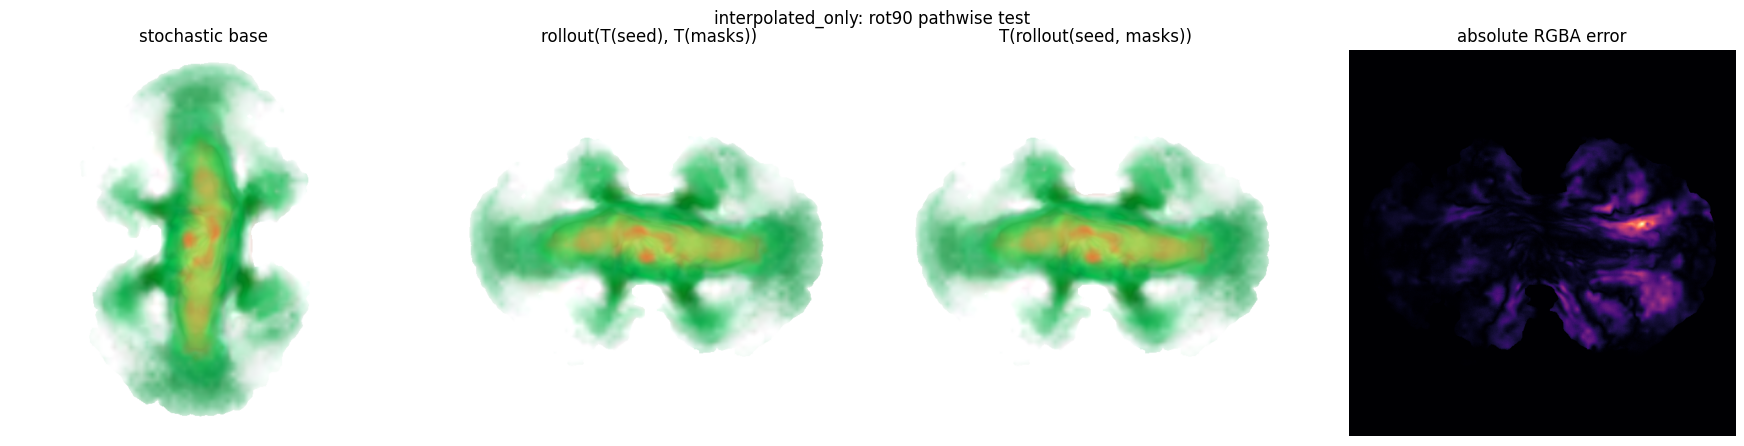

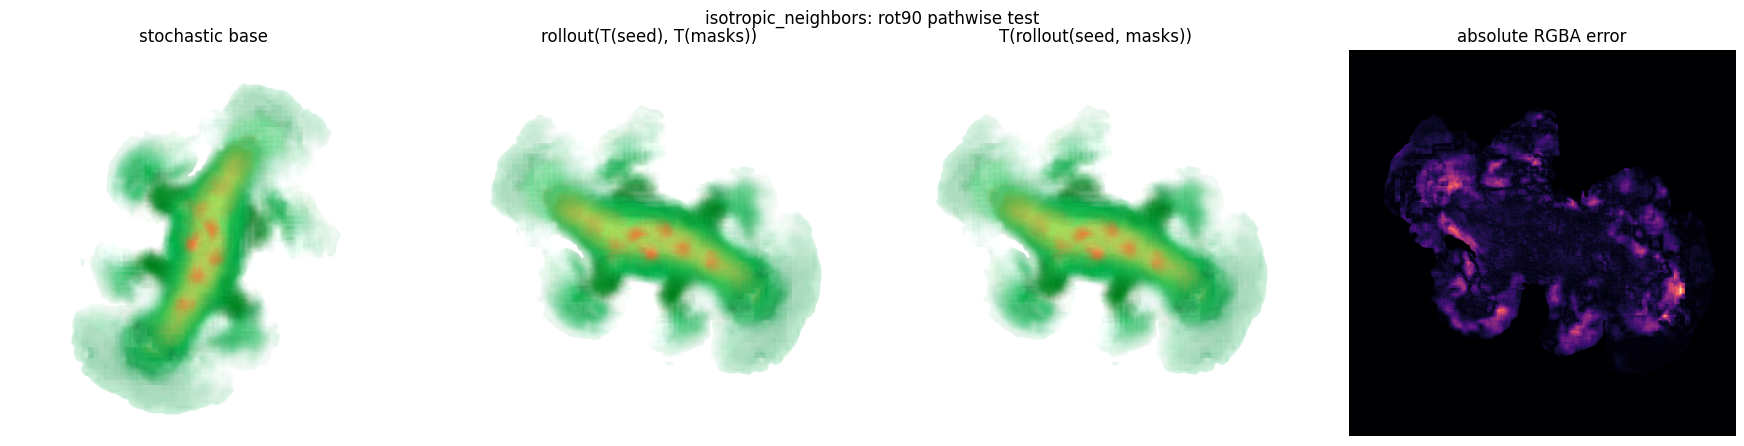

variant | invariant_target_loss | edge_energy | boundary/interior gradient
interpolated_only | 96.255 | 0.0030123 | 1.031
isotropic_neighbors | 70.616 | 0.0033281 | 0.84258


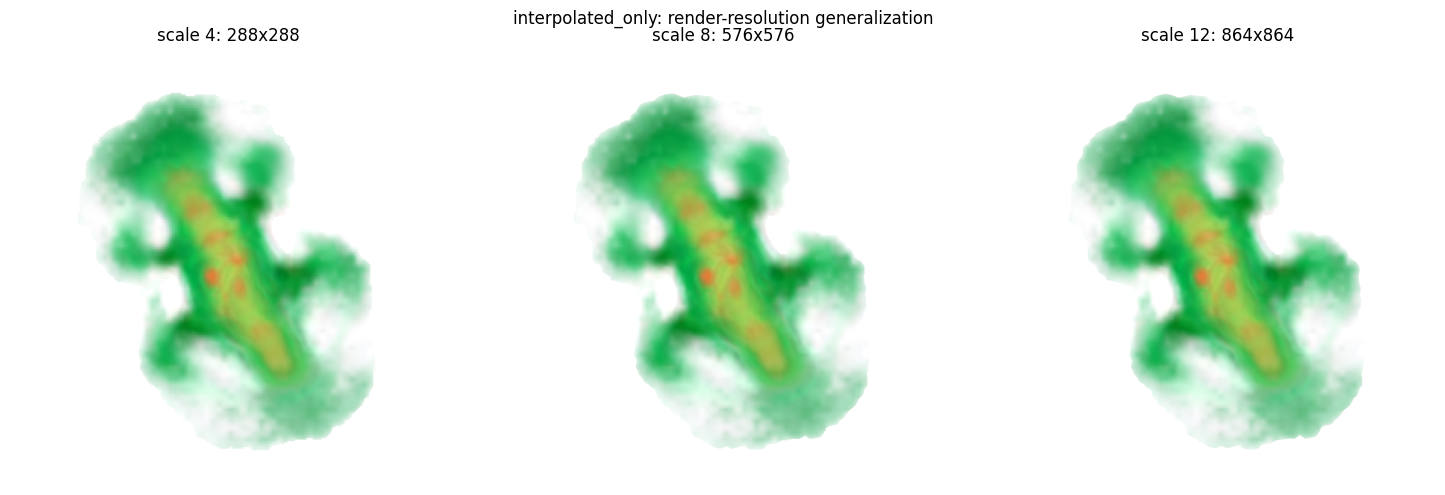

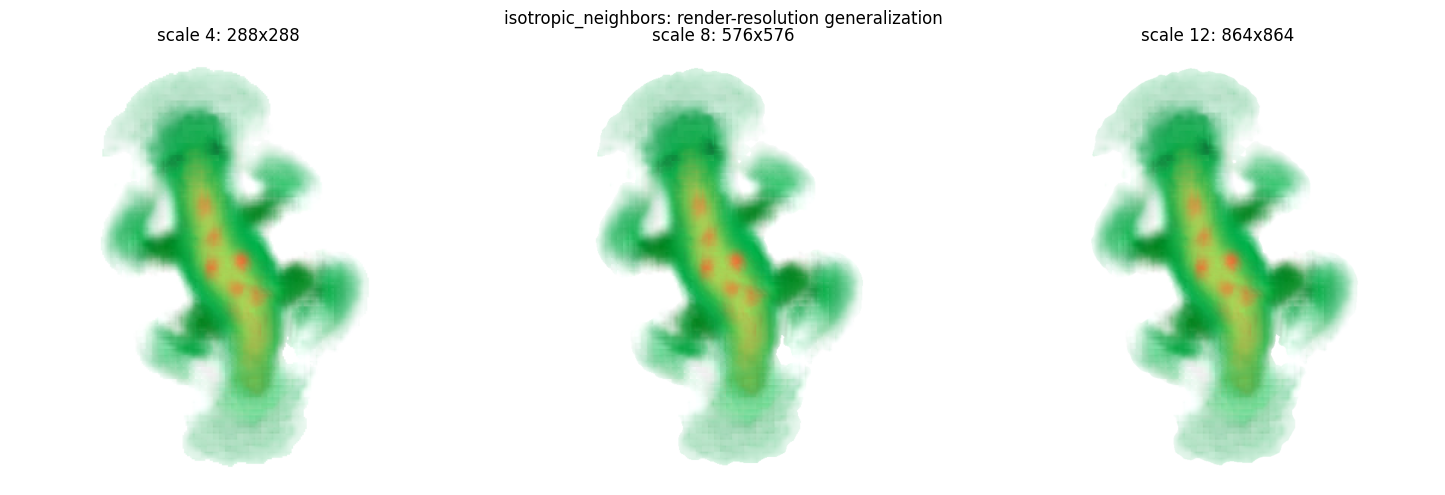

In [16]:
#@title Comparison visuals and simple detail/boundary metrics
def edge_energy(image):
    rgb = image[..., :3] * image[..., 3:4].clamp(0.0, 1.0)
    dx = (rgb[:, :, 1:] - rgb[:, :, :-1]).abs().mean()
    dy = (rgb[:, 1:] - rgb[:, :-1]).abs().mean()
    return (dx + dy).item()

def primitive_boundary_ratio(image, scale_factor=SCALE_FACTOR):
    rgb = image[..., :3] * image[..., 3:4].clamp(0.0, 1.0)
    dx = (rgb[:, :, 1:] - rgb[:, :, :-1]).abs().mean(dim=-1)
    dy = (rgb[:, 1:] - rgb[:, :-1]).abs().mean(dim=-1)
    x_boundary = torch.arange(dx.shape[-1], device=dx.device) % scale_factor == scale_factor - 1
    y_boundary = torch.arange(dy.shape[-2], device=dy.device) % scale_factor == scale_factor - 1
    boundary = torch.cat([dx[..., x_boundary].reshape(-1), dy[:, y_boundary].reshape(-1)]).mean()
    interior = torch.cat([dx[..., ~x_boundary].reshape(-1), dy[:, ~y_boundary].reshape(-1)]).mean()
    return (boundary / (interior + 1e-8)).item()

for name, result in pathwise_results.items():
    base = result['base'][0].numpy()
    transformed = result['rot90']['actual'][0].numpy()
    expected = result['rot90']['expected'][0].numpy()
    error = result['rot90']['error'][0, ..., :4].mean(-1).numpy()
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    axes[0].imshow(composite_rgba(base[..., :4])); axes[0].set_title('stochastic base')
    axes[1].imshow(composite_rgba(transformed[..., :4])); axes[1].set_title('rollout(T(seed), T(masks))')
    axes[2].imshow(composite_rgba(expected[..., :4])); axes[2].set_title('T(rollout(seed, masks))')
    axes[3].imshow(error, cmap='magma'); axes[3].set_title('absolute RGBA error')
    for axis in axes: axis.axis('off')
    fig.suptitle(name + ': rot90 pathwise test'); plt.tight_layout(); plt.show()

print('variant | invariant_target_loss | edge_energy | boundary/interior gradient')
for name, item in completed.items():
    image = pathwise_results[name]['base'].to(device)
    state_alpha = pathwise_results[name]['nca_alpha'].to(device)
    target_loss, _, _ = item['loss_fn'](
        {'generated_images': image.permute(0, 3, 1, 2), 'alpha': state_alpha},
        return_summary=False,
    )
    print(f'{name} | {target_loss.item():.5g} | {edge_energy(image):.5g} | {primitive_boundary_ratio(image):.5g}')

# Resolution-generalization spot check from the same final NCA state.
for name, item in completed.items():
    model = item['model']; h, w = item['grid_size']
    generator = torch.Generator(device=device).manual_seed(12000)
    masks = (torch.rand(EVAL_STEPS, 1, 1, h, w, device=device, generator=generator) < UPDATE_PROB).to(PRECISION)
    with torch.no_grad():
        state = rollout_with_masks(model, make_seed(model, 1, h, w), masks)
        images = [render_channels(name, model, item['decoder'], item['renderer'], state, scale_factor=scale).cpu()[0].numpy() for scale in [4, 8, 12]]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for axis, scale, image in zip(axes, [4, 8, 12], images):
        axis.imshow(composite_rgba(image[..., :4])); axis.set_title(f'scale {scale}: {image.shape[0]}x{image.shape[1]}'); axis.axis('off')
    fig.suptitle(name + ': render-resolution generalization'); plt.tight_layout(); plt.show()